## RQ 7: During the span of the last 15 years, when did **München** score goals most often in their opponent's city?

In [13]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

In [39]:
inputID = 40        


# choose any other team playing in the last 15 seasons
# possible teams: Mainz 81, Hoffenheim 175, Leverkusen 6,  
# München 40, Dortmund 7, Mönchengladbach 87, Wolfsburg 131

# source: http://www.bulibox.de/bundesliga/jahrestabelle-2010-1.liga.html

In [ ]:
### for given team: get goals home and away per season

input_name = None
result = {}
# year: goals_home, goal_away

for x in range(15):
    # get all matches for the last 15 years
    season = 2009 + x
    result[season] = {'season': season, 'goals_home': 0, 'goals_away': 0}
    url = "https://api.openligadb.de/getmatchdata/bl1/" + str(season)
    response = requests.get(url)
    response = response.json()
    
    # get total number of goals home and away
    for match in response:
        if match['team1']['teamId'] == inputID or match['team2']['teamId'] == inputID:
            goals = match ['goals']
            score1 = 0
            score2 = 0        
            for goal in goals:
                score1new = goal ['scoreTeam1'] 
                score2new = goal ['scoreTeam2']
                if score1new > score1:      # goal home
                    result[season]['goals_home'] += 1
                    score1 = score1new
                else:       # goal away
                    result[season]['goals_away'] += 1
                    score2 = score2new
            
            # get input team name
            if input_name == None:
                if match['team1']['teamId'] == inputID:
                    input_name = match['team1']['teamName']
                else: 
                    input_name = match['team2']['teamName']

{'matchID': 5282, 'matchDateTime': '2009-08-08T18:30:00', 'timeZoneID': 'W. Europe Standard Time', 'leagueId': 71, 'leagueName': '1. Fussball-Bundesliga 2009/2010', 'leagueSeason': 2009, 'leagueShortcut': 'bl1', 'matchDateTimeUTC': '2009-08-08T16:30:00Z', 'group': {'groupName': '1. Spieltag', 'groupOrderID': 1, 'groupID': 11538}, 'team1': {'teamId': 175, 'teamName': 'TSG Hoffenheim', 'shortName': 'Hoffenheim', 'teamIconUrl': 'https://i.imgur.com/gF0PfEl.png', 'teamGroupName': None}, 'team2': {'teamId': 40, 'teamName': 'FC Bayern München', 'shortName': 'Bayern', 'teamIconUrl': 'https://www.openligadb.de/images/teamicons/Bayern_Muenchen.gif', 'teamGroupName': None}, 'lastUpdateDateTime': '2009-08-14T18:39:58.347', 'matchIsFinished': True, 'matchResults': [{'resultID': 6193, 'resultName': 'Endergebnis', 'pointsTeam1': 1, 'pointsTeam2': 1, 'resultOrderID': 1, 'resultTypeID': 2, 'resultDescription': 'Ergebnis nach Ende der offiziellen Spielzeit'}, {'resultID': 6194, 'resultName': 'Halbzeite

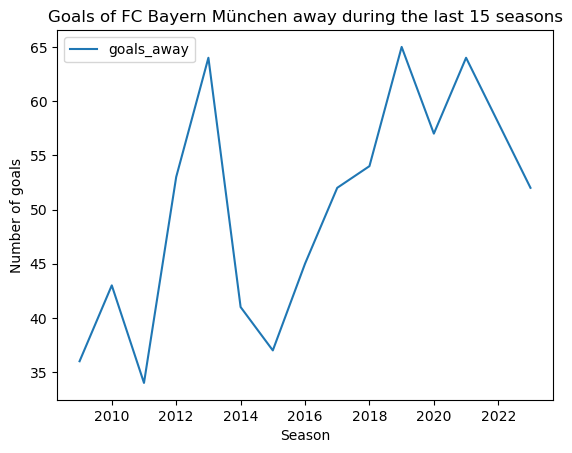

In [37]:
### visualize results for given team

# convert to dataframe
df = pd.DataFrame.from_dict(result)
df = df.transpose()

# plot the data
df.plot(x = 'season', y = 'goals_away')
plt.title('Goals of ' + input_name + ' away during the last 15 seasons')
plt.xlabel('Season')
plt.ylabel('Number of goals')
plt.show()